In [2]:
pip install matplotlib seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 3.9 MB/s  0:00:02 eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 4.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m6/7 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

project_root = ".."
results_dir = os.path.join(project_root, "results")
validation_csv_path = os.path.join(results_dir, "features_validation_set.csv")

print(f"Loading data from: {validation_csv_path}")
try:
    df = pd.read_csv(validation_csv_path)
    print("Data loaded successfully!")
    print(f"Shape of the dataset: {df.shape}")
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nData Info:")
    df.info()
except FileNotFoundError:
    print(f"Error: The file was not found at {validation_csv_path}")
    print("Please make sure you have run the 'run_batch_processing.py' script successfully.")

Loading data from: ../results/features_validation_set.csv
Data loaded successfully!
Shape of the dataset: (2394, 11)

First 5 rows:


,filepath,category,snr,start_time,end_time,transcription,avg_logprob,lexical_validity,perplexity,silero_speech_prob,whisper_no_speech_prob
0,/Users/sandhya/Desktop/CGS/GCS_Speech_Thesis/d...,gcs_2,NaN,0.000,1.376,Da...,-1.239414,1.0,297.991333,0.027010,0.508614
1,/Users/sandhya/Desktop/CGS/GCS_Speech_Thesis/d...,gcs_2,NaN,3.936,5.000,Die Erinnerungs-Geräuschung,-1.670058,0.5,1359.900879,0.002791,0.537596
2,/Users/sandhya/Desktop/CGS/GCS_Speech_Thesis/d...,gcs_2,NaN,0.000,2.336,...,-1.315538,0.0,NaN,0.000053,0.518599
3,/Users/sandhya/Desktop/CGS/GCS_Speech_Thesis/d...,gcs_2,NaN,0.768,0.992,...,-1.520945,0.0,NaN,0.000015,0.593446
4,/Users/sandhya/Desktop/CGS/GCS_Speech_Thesis/d...,gcs_2,NaN,1.888,2.848,Ah!,-1.311894,0.0,14.109509,0.000036,0.544688



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 2394 entries, 0 to 2393
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   filepath                2394 non-null   str    
 1   category                2394 non-null   str    
 2   snr                     1573 non-null   float64
 3   start_time              2394 non-null   float64
 4   end_time                2394 non-null   float64
 5   transcription           2394 non-null   str    
 6   avg_logprob             2394 non-null   float64
 7   lexical_validity        2394 non-null   float64
 8   perplexity              2347 non-null   float64
 9   silero_speech_prob      2394 non-null   float64
 10  whisper_no_speech_prob  2394 non-null   float64
dtypes: float64(8), str(3)
memory usage: 205.9 KB


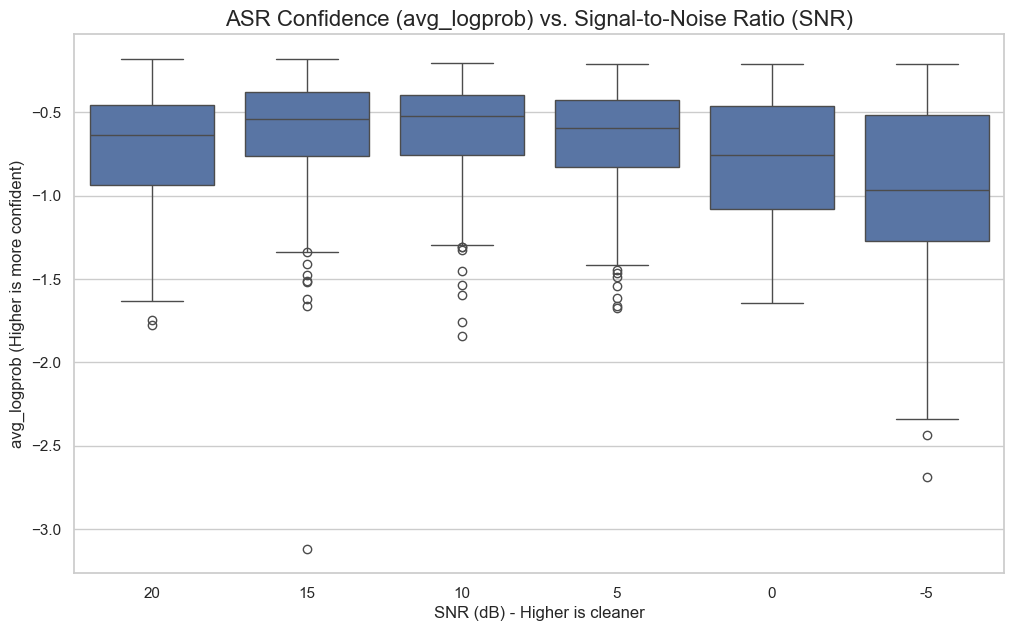

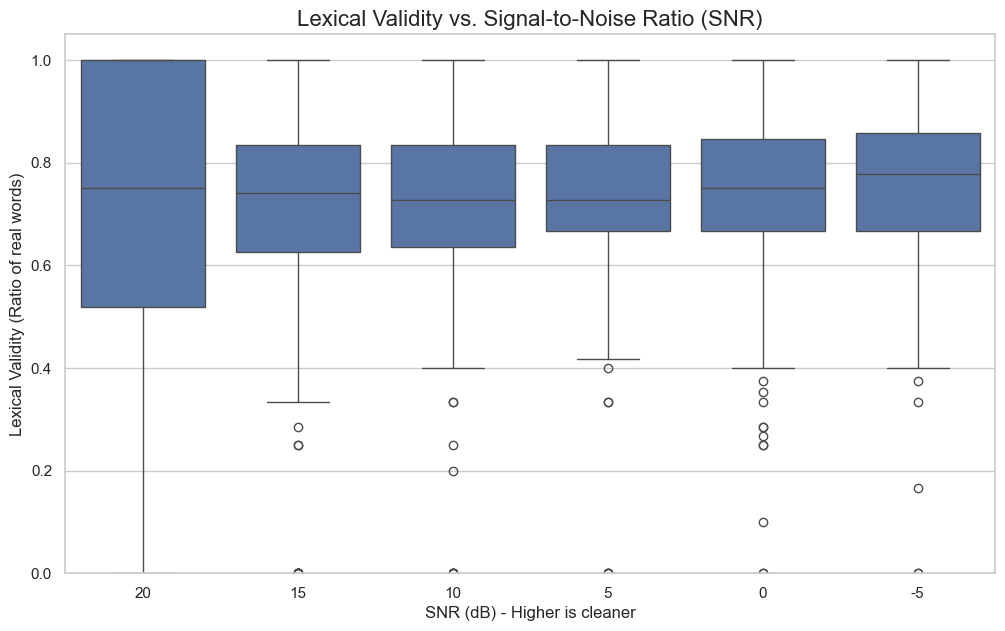

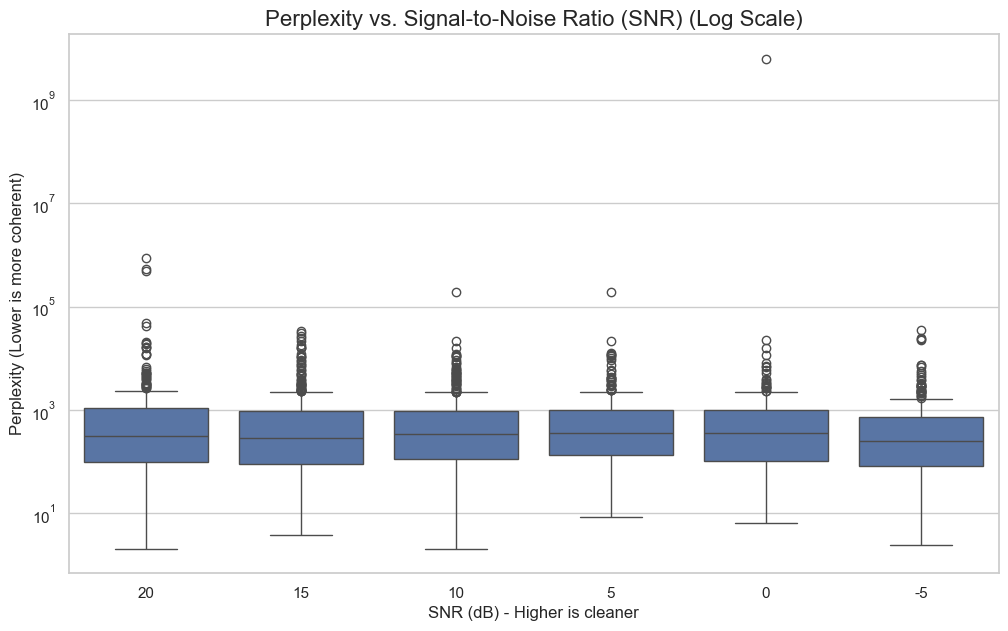

In [2]:
# Filter the DataFrame to only include the relevant data
# Clean GCS 4/5 as our baseline (snr=infinity) and the noisy GCS 4/5 data.
noise_analysis_df = df[df['category'].isin(['gcs_45_clean', 'gcs_45_noisy'])].copy()

# To have a consistent SNR value for the clean data
# Fill the NaN SNR values for the 'gcs_45_clean' category with a high number like 20 for plotting.
noise_analysis_df['snr'] = noise_analysis_df['snr'].fillna(20) 
noise_analysis_df['snr'] = noise_analysis_df['snr'].astype(int)

# --- Plot 1: ASR Confidence (avg_logprob) vs. SNR ---
plt.figure(figsize=(12, 7))
sns.boxplot(x='snr', y='avg_logprob', data=noise_analysis_df, order=[20, 15, 10, 5, 0, -5])
plt.title('ASR Confidence (avg_logprob) vs. Signal-to-Noise Ratio (SNR)', fontsize=16)
plt.xlabel('SNR (dB) - Higher is cleaner', fontsize=12)
plt.ylabel('avg_logprob (Higher is more confident)', fontsize=12)
plt.show()

# --- Plot 2: Lexical Validity vs. SNR ---
plt.figure(figsize=(12, 7))
sns.boxplot(x='snr', y='lexical_validity', data=noise_analysis_df, order=[20, 15, 10, 5, 0, -5])
plt.title('Lexical Validity vs. Signal-to-Noise Ratio (SNR)', fontsize=16)
plt.xlabel('SNR (dB) - Higher is cleaner', fontsize=12)
plt.ylabel('Lexical Validity (Ratio of real words)', fontsize=12)
plt.ylim(0, 1.05) # Set y-axis from 0 to 1
plt.show()

# --- Plot 3: Perplexity vs. SNR ---
# Logarithmic scale to handle the large range of values
plt.figure(figsize=(12, 7))
sns.boxplot(x='snr', y='perplexity', data=noise_analysis_df, order=[20, 15, 10, 5, 0, -5])
plt.yscale('log') # Use a logarithmic scale for the y-axis
plt.title('Perplexity vs. Signal-to-Noise Ratio (SNR) (Log Scale)', fontsize=16)
plt.xlabel('SNR (dB) - Higher is cleaner', fontsize=12)
plt.ylabel('Perplexity (Lower is more coherent)', fontsize=12)
plt.show()